Cumulative Precipitation:
Date
2014-01-03    0.168
2014-01-04    0.168
2014-01-05    0.396
2014-01-06    4.146
2014-01-07    4.245
2014-01-08    4.647
2014-01-09    6.792
2014-01-10    8.469
2014-01-11    9.597
2014-01-12    9.801
Name: PR, dtype: float64

Cumulative Noah-MP ET:
Date
2014-01-03    0.082850
2014-01-04    0.099231
2014-01-05    0.113161
2014-01-06    0.403636
2014-01-07    0.619606
2014-01-08    0.883118
2014-01-09    1.267504
2014-01-10    1.782392
2014-01-11    2.016717
2014-01-12    2.155618
Name: Noah_MP_ET, dtype: float64


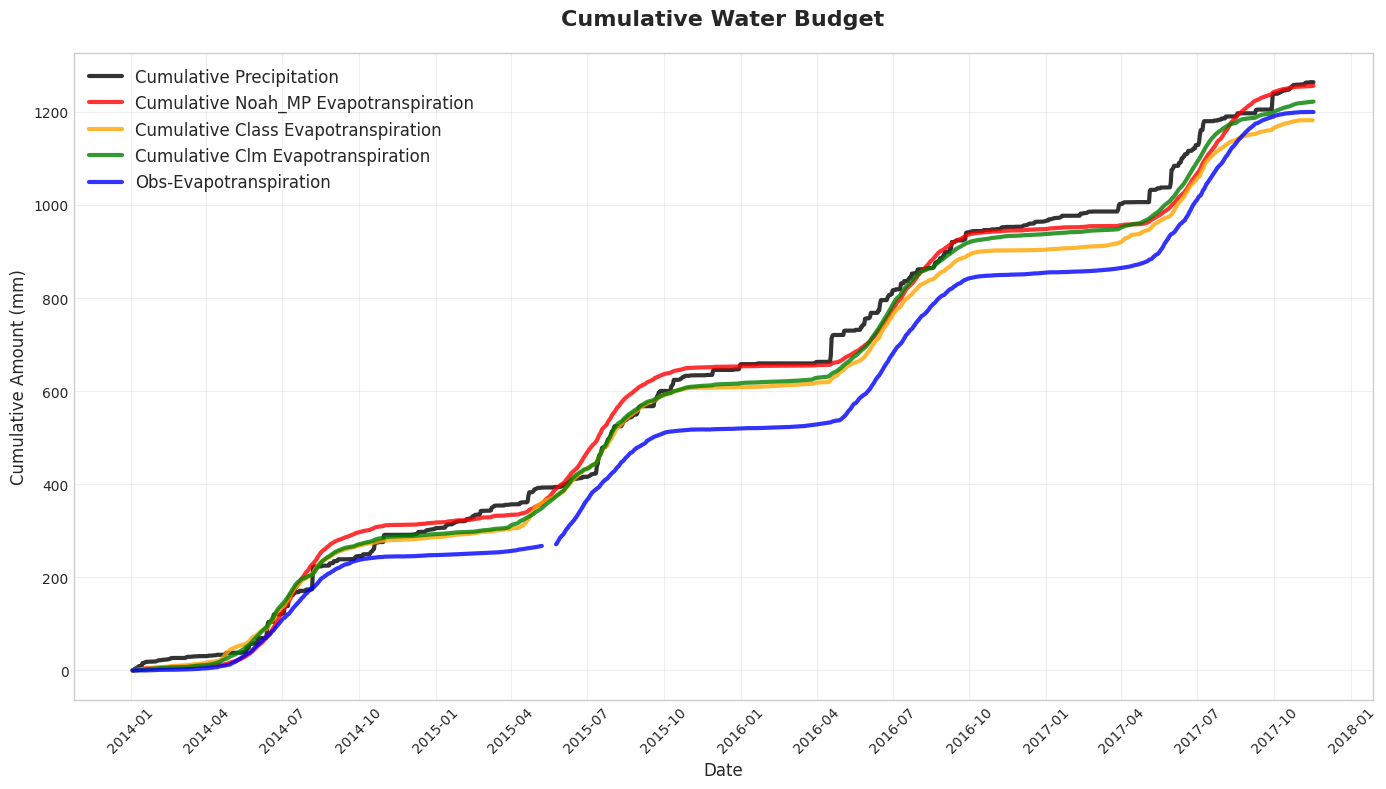

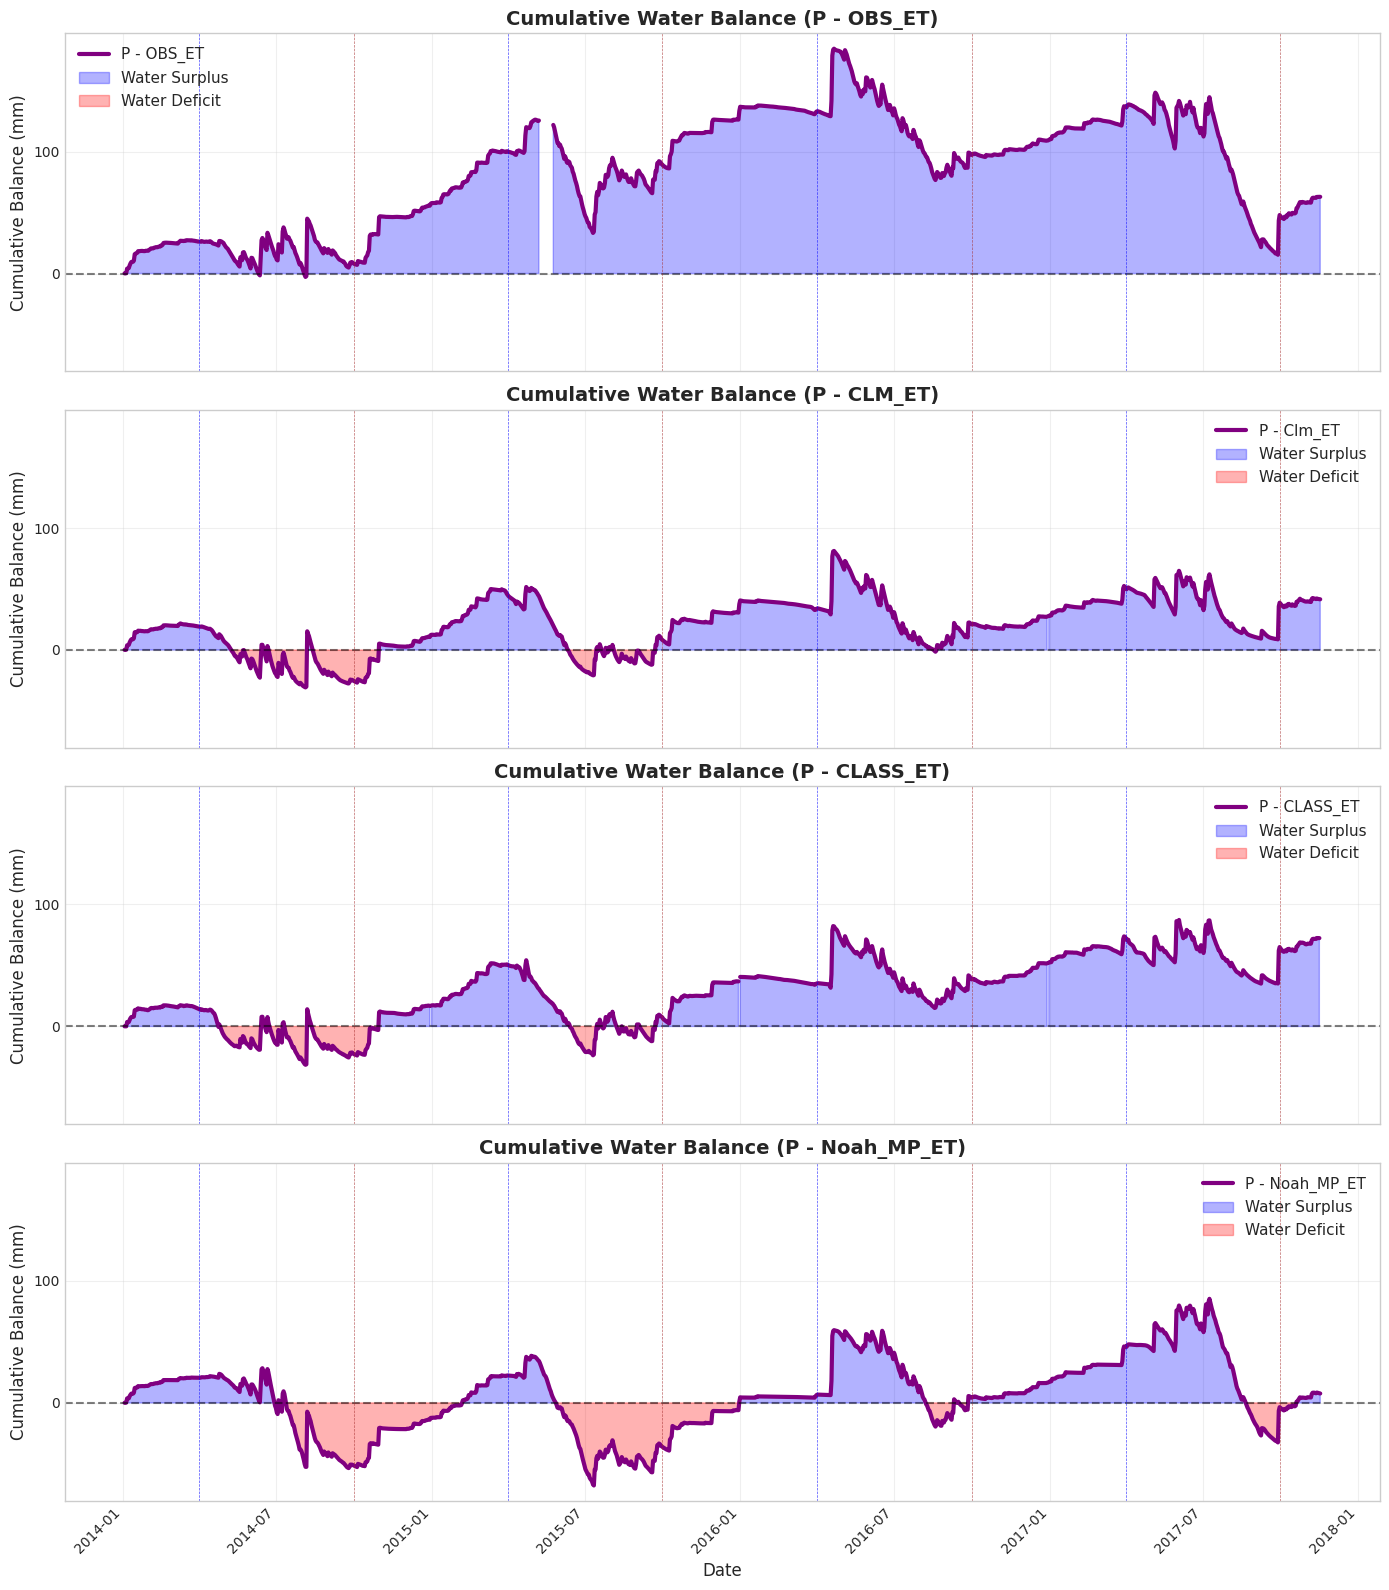

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator          # 修改：用于统一刻度间隔
from pathlib import Path
import seaborn as sns
from datetime import datetime, timedelta

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')                # 修改：新版 matplotlib 的样式名
sns.set_palette("husl")

# Load data
BASE_PATH1 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/")
filename1 = "ET_data.csv"
filename2 = "PR_SM_T2_data.csv"
fullpath1 = BASE_PATH1 / filename1
fullpath2 = BASE_PATH1 / filename2

df_ET = pd.read_csv(fullpath1, low_memory=False)
df_PR = pd.read_csv(fullpath2, low_memory=False)

df_ET['Date'] = pd.to_datetime(df_ET['Date'])
df_PR['Date'] = pd.to_datetime(df_PR['Date'])

df_ET = df_ET.set_index('Date')
df_PR = df_PR.set_index('Date')

# Extract data
Noah_ET = df_ET['Noah_MP_ET'].astype(float)
PR = df_ET['PR'].astype(float)
CLM_ET = df_ET['CLM_ET'].astype(float)                 # 修改：统一转为 float
CLASS_ET = df_ET['CLASS_ET'].astype(float)
OBS_ET = df_ET['OBS_ET'].astype(float)

# Cumulative values
PR_cum = PR.cumsum()
ET_Noah_cum = Noah_ET.cumsum()
ET_Clm_cum = CLM_ET.cumsum()
ET_Class_cum = CLASS_ET.cumsum()
ET_Obs_cum = OBS_ET.cumsum()

print("Cumulative Precipitation:")
print(PR_cum.head(10))
print("\nCumulative Noah-MP ET:")
print(ET_Noah_cum.head(10))

# =============================================================================
# 1. Basic cumulative plot
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(PR_cum.index, PR_cum.values, 'k-', linewidth=3, label='Cumulative Precipitation', alpha=0.8)
ax.plot(ET_Noah_cum.index, ET_Noah_cum.values, 'r-', linewidth=3, label='Cumulative Noah_MP Evapotranspiration', alpha=0.8)
ax.plot(ET_Class_cum.index, ET_Class_cum.values, color='orange', linewidth=3, label='Cumulative Class Evapotranspiration', alpha=0.8)  # 修改：'o-' 是圆点标记，不是橙色
ax.plot(ET_Clm_cum.index, ET_Clm_cum.values, 'g-', linewidth=3, label='Cumulative Clm Evapotranspiration', alpha=0.8)
ax.plot(ET_Obs_cum.index, ET_Obs_cum.values, 'b-', linewidth=3, label='Obs-Evapotranspiration', alpha=0.8)
ax.set_title('Cumulative Water Budget', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Amount (mm)', fontsize=12)
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# =============================================================================
# 2. Water balance analysis
# =============================================================================
water_balance_Noah = PR - Noah_ET
water_balance_Noah_cum = water_balance_Noah.cumsum()
water_balance_Class = PR - CLASS_ET
water_balance_Class_cum = water_balance_Class.cumsum()
water_balance_Clm = PR - CLM_ET
water_balance_Clm_cum = water_balance_Clm.cumsum()
water_balance_Obs = PR - OBS_ET
water_balance_Obs_cum = water_balance_Obs.cumsum()

fig, (ax2, ax3, ax4, ax5) = plt.subplots(4, 1, figsize=(14, 16), sharex=True)  # 修改：共享 x 轴，图高一些

# Top plot - all cumulative components
'''
ax1.plot(PR_cum.index, PR_cum.values, 'k-', linewidth=3, label='Precipitation', alpha=0.8)
ax1.plot(ET_Noah_cum.index, ET_Noah_cum.values, 'r-', linewidth=3, label='Noah-Evapotranspiration', alpha=0.8)
ax1.plot(ET_Clm_cum.index, ET_Clm_cum.values, 'g-', linewidth=3, label='Clm-Evapotranspiration', alpha=0.8)
ax1.plot(ET_Class_cum.index, ET_Class_cum.values, color='orange', linewidth=3, label='Class-Evapotranspiration', alpha=0.8)  # 修改
ax1.plot(ET_Obs_cum.index, ET_Obs_cum.values, 'b-', linewidth=3, label='Obs-Evapotranspiration', alpha=0.8)
ax1.set_title('Cumulative Water Budget Components', fontsize=14, fontweight='bold')
#ax1.set_ylabel('Cumulative Amount (mm)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
'''
# Second plot - P - OBS_ET
ax2.plot(water_balance_Obs_cum.index, water_balance_Obs_cum.values, 'purple', linewidth=3, label='P - OBS_ET')
ax2.fill_between(water_balance_Obs_cum.index, water_balance_Obs_cum.values, 0,
                 where=(water_balance_Obs_cum.values >= 0), interpolate=True, alpha=0.3, color='blue', label='Water Surplus')
ax2.fill_between(water_balance_Obs_cum.index, water_balance_Obs_cum.values, 0,
                 where=(water_balance_Obs_cum.values < 0), interpolate=True, alpha=0.3, color='red', label='Water Deficit')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Cumulative Water Balance (P - OBS_ET)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Cumulative Balance (mm)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Third plot - P - CLM_ET
ax3.plot(water_balance_Clm_cum.index, water_balance_Clm_cum.values, 'purple', linewidth=3, label='P - Clm_ET')
ax3.fill_between(water_balance_Clm_cum.index, water_balance_Clm_cum.values, 0,
                 where=(water_balance_Clm_cum.values >= 0), interpolate=True, alpha=0.3, color='blue', label='Water Surplus')
ax3.fill_between(water_balance_Clm_cum.index, water_balance_Clm_cum.values, 0,
                 where=(water_balance_Clm_cum.values < 0), interpolate=True, alpha=0.3, color='red', label='Water Deficit')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('Cumulative Water Balance (P - CLM_ET)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Cumulative Balance (mm)', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Fourth plot - P - CLASS_ET
ax4.plot(water_balance_Class_cum.index, water_balance_Class_cum.values, 'purple', linewidth=3, label='P - CLASS_ET')
ax4.fill_between(water_balance_Class_cum.index, water_balance_Class_cum.values, 0,
                 where=(water_balance_Class_cum.values >= 0), interpolate=True, alpha=0.3, color='blue', label='Water Surplus')
ax4.fill_between(water_balance_Class_cum.index, water_balance_Class_cum.values, 0,
                 where=(water_balance_Class_cum.values < 0), interpolate=True, alpha=0.3, color='red', label='Water Deficit')
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax4.set_title('Cumulative Water Balance (P - CLASS_ET)', fontsize=14, fontweight='bold')
ax4.set_ylabel('Cumulative Balance (mm)', fontsize=12)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

# Fifth plot - P - Noah_MP_ET
ax5.plot(water_balance_Noah_cum.index, water_balance_Noah_cum.values, 'purple', linewidth=3, label='P - Noah_MP_ET')
ax5.fill_between(water_balance_Noah_cum.index, water_balance_Noah_cum.values, 0,
                 where=(water_balance_Noah_cum.values >= 0), interpolate=True, alpha=0.3, color='blue', label='Water Surplus')
ax5.fill_between(water_balance_Noah_cum.index, water_balance_Noah_cum.values, 0,
                 where=(water_balance_Noah_cum.values < 0), interpolate=True, alpha=0.3, color='red', label='Water Deficit')
ax5.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax5.set_title('Cumulative Water Balance (P - Noah_MP_ET)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Date', fontsize=12)
ax5.set_ylabel('Cumulative Balance (mm)', fontsize=12)
# ax5.set_ylim(bottom=-150)                            # 修改：删除，只作用于这一个图
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# 修改：四个 water balance 图使用相同的纵坐标范围
# ---------------------------------------------------------------------------
wb_all = [water_balance_Obs_cum, water_balance_Clm_cum,
          water_balance_Class_cum, water_balance_Noah_cum]
ymin = min(s.min() for s in wb_all)
ymax = max(s.max() for s in wb_all)
pad = 0.05 * (ymax - ymin)                             # 上下各留 5% 空白

for ax in [ax2, ax3, ax4, ax5]:
    ax.set_ylim(ymin - pad, ymax + pad)
    # ax.set_ylim(-400, 200)                           # 或者手动指定固定范围
    ax.yaxis.set_major_locator(MultipleLocator(100))   # 刻度间隔 100 mm，可按需修改

# Growing-season lines
for year in range(2014, 2018):
    date1 = datetime(year, 4, 1)
    date2 = datetime(year, 10, 1)
    for ax in [ax2, ax3, ax4, ax5]:
        ax.axvline(x=date1, color='blue', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.axvline(x=date2, color='brown', linestyle='--', linewidth=0.5, alpha=0.7)

# Format dates (sharex=True，设置一次即可作用于所有子图)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax5.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
fig.autofmt_xdate(rotation=45)                         # 修改：替代 plt.xticks，只在底部显示日期

plt.tight_layout()
OUT_DIR =Path('/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/')
fig.savefig(OUT_DIR / "cumulative_water_balance.png", dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / "cumulative_water_balance.pdf", bbox_inches='tight')   # 矢量图，投稿用

plt.show()
